<a href="https://colab.research.google.com/github/erdilix/nma-compneu2026/blob/main/projects/behavior_and_theory/earth_laquitaine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Bayesian observer for motion-direction estimation

Reworked from the Laquitaine & Gardner prior-learning demo into a minimal **Bayesian inference** model, built step by step following **W3D2 Bayesian Decisions, Tutorial 2** (continuous state: Gaussian prior × Gaussian likelihood = Gaussian posterior).

Inspired by [Laquitaine & Gardner, Neuron, 2017](https://www.cell.com/neuron/fulltext/S0896-6273(17)31134-0).

**The plan.** Each cell adds one piece. Run them top to bottom:

1. Set up the state space (all possible motion directions).
2. Build the **prior** — directions the experiment shows more often.
3. Build the **likelihood** — this trial's noisy sensory measurement.
4. Apply **Bayes rule** — multiply and normalize to get the **posterior**.
5. Read out the estimate (MAP) and see the **bias toward the prior**.
6. Sweep many trials to see the classic effect: weaker signal → stronger prior pull.

In [1]:
# @title Dependencies
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['figure.figsize'] = [8, 4]
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

## Step 0 — one helper: a Gaussian on a grid

Both the prior and the likelihood are Gaussians evaluated on the same grid of directions. This is the `my_gaussian` from W3D2 Tutorial 2, normalized so it sums to 1 on the discrete grid.

In [2]:
def my_gaussian(x, mu, sigma):
    """Gaussian probability density over the state space x (normalized on the grid)."""
    px = np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / np.sqrt(2 * np.pi * sigma ** 2)
    return px / px.sum()

## Step 1 — the state space

All motion directions the observer could report, in degrees.

In [3]:
x = np.arange(1, 360, 1)   # motion directions (deg)
print('state space:', x[0], '...', x[-1], 'deg  (', len(x), 'points )')

state space: 1 ... 359 deg  ( 359 points )


## Step 2 — the prior

The experiment shows some directions more often. The observer's prior is a Gaussian centred on that most-frequent direction. `PRIOR_SIGMA` sets how strong (narrow) the prior belief is.

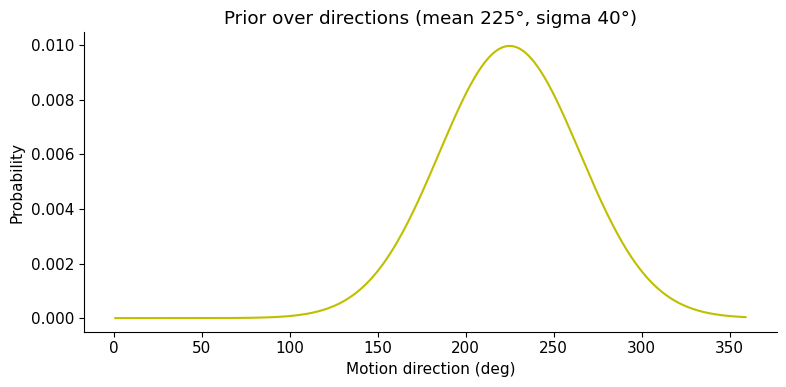

In [18]:
PRIOR_MEAN = 225    # most frequent direction (deg)
PRIOR_SIGMA = 40    # prior width: smaller = stronger prior

prior = my_gaussian(x, PRIOR_MEAN, PRIOR_SIGMA)

plt.plot(x, prior, color=[0.75, 0.75, 0])
plt.title(f'Prior over directions (mean {PRIOR_MEAN}°, sigma {PRIOR_SIGMA}°)')
plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
plt.show()

In [14]:
from ipywidgets import interact, IntSlider

def plot_prior(PRIOR_MEAN, PRIOR_SIGMA):
    prior = my_gaussian(x, PRIOR_MEAN, PRIOR_SIGMA)

    plt.plot(x, prior, color=[0.75, 0.75, 0])
    plt.title(f'Prior over directions (mean {PRIOR_MEAN}°, sigma {PRIOR_SIGMA}°)')
    plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
    plt.ylim([0, 0.45]) # Keep y-axis consistent for better comparison
    plt.show()

interact(plot_prior,
         PRIOR_MEAN=IntSlider(min=0, max=360, step=1, value=225, description='Prior Mean'),
         PRIOR_SIGMA=IntSlider(min=1, max=100, step=1, value=1, description='Prior Sigma'))

interactive(children=(IntSlider(value=225, description='Prior Mean', max=360), IntSlider(value=1, description=…

<function __main__.plot_prior(PRIOR_MEAN, PRIOR_SIGMA)>

## Step 3 — the likelihood

On a trial the observer gets a noisy sensory measurement of the true direction. The likelihood is a Gaussian centred on that measurement; its width `SENSORY_SIGMA` encodes signal quality — small = strong signal (high coherence), large = weak signal.

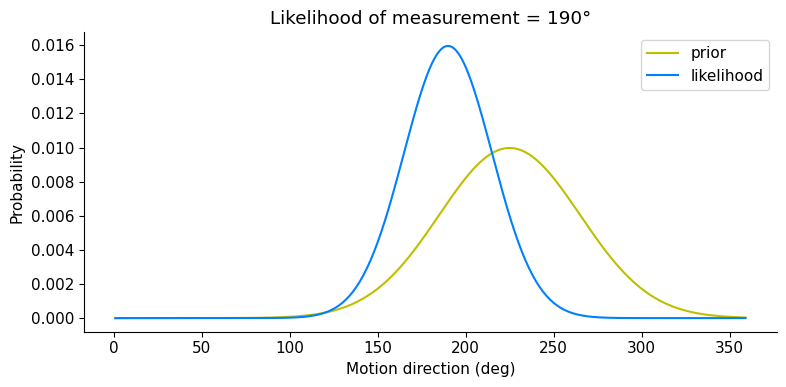

In [19]:
MEASUREMENT = 190     # measured direction this trial (deg)
SENSORY_SIGMA = 25    # likelihood width: small = strong signal

likelihood = my_gaussian(x, MEASUREMENT, SENSORY_SIGMA)

plt.plot(x, prior, color=[0.75, 0.75, 0], label='prior')
plt.plot(x, likelihood, color=[0, 0.5, 1], label='likelihood')
plt.title(f'Likelihood of measurement = {MEASUREMENT}°')
plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
plt.legend(); plt.show()

In [21]:
from ipywidgets import interact, IntSlider

def plot_likelihood(MEASUREMENT, SENSORY_SIGMA):
    likelihood = my_gaussian(x, MEASUREMENT, SENSORY_SIGMA)

    plt.plot(x, prior, color=[0.75, 0.75, 0], label='prior')
    plt.plot(x, likelihood, color=[0, 0.5, 1], label='likelihood')
    plt.title(f'Likelihood of measurement = {MEASUREMENT}°')
    plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
    #plt.ylim([0, 0.45]) # Keep y-axis consistent for better comparison
    plt.show()

interact(plot_likelihood,
         MEASUREMENT=IntSlider(min=0, max=360, step=1, value=190, description='Measurement'),
         SENSORY_SIGMA=IntSlider(min=1, max=100, step=1, value=25, description='Sensory Sigma'))

interactive(children=(IntSlider(value=190, description='Measurement', max=360), IntSlider(value=25, descriptio…

<function __main__.plot_likelihood(MEASUREMENT, SENSORY_SIGMA)>

## Step 4 — Bayes rule: posterior = prior × likelihood

Multiply the two distributions pointwise, then normalize so the result is a true PDF. This is the whole of Bayesian inference on a grid.

In [6]:
def compute_posterior(prior, likelihood):
    """Bayes rule on a grid: posterior proportional to prior * likelihood."""
    posterior = np.multiply(prior, likelihood)
    return posterior / posterior.sum()

posterior = compute_posterior(prior, likelihood)

## Step 5 — read out the estimate and see the prior bias

The observer reports the peak of the posterior (the MAP estimate). It lands **between** the measurement and the prior mean — the estimate is pulled toward the prior.

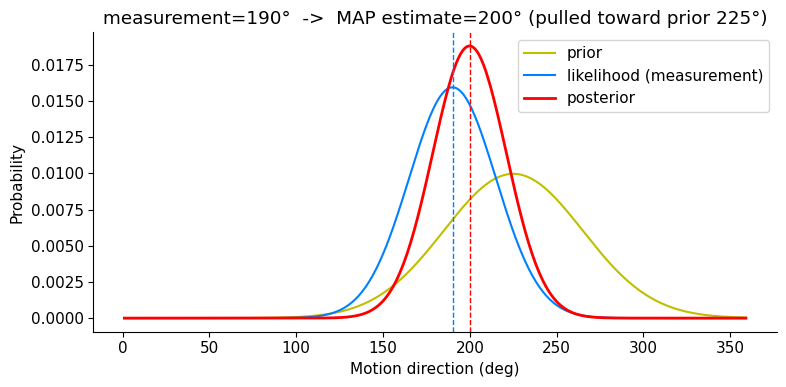

measurement      : 190 deg
MAP estimate     : 200 deg
bias toward prior: +10 deg


In [22]:
estimate = x[np.argmax(posterior)]   # MAP readout

plt.plot(x, prior, label='prior', color=[0.75, 0.75, 0])
plt.plot(x, likelihood, label='likelihood (measurement)', color=[0, 0.5, 1])
plt.plot(x, posterior, label='posterior', color=[1, 0, 0], lw=2)
plt.axvline(MEASUREMENT, color=[0, 0.5, 1], ls='--', lw=1)
plt.axvline(estimate, color=[1, 0, 0], ls='--', lw=1)
plt.title(f'measurement={MEASUREMENT}°  ->  MAP estimate={estimate}° (pulled toward prior {PRIOR_MEAN}°)')
plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
plt.legend(); plt.show()

print(f'measurement      : {MEASUREMENT} deg')
print(f'MAP estimate     : {estimate} deg')
print(f'bias toward prior: {estimate - MEASUREMENT:+d} deg')

Try re-running Step 3 with a larger `SENSORY_SIGMA` (weaker signal) and watch the estimate move closer to the prior mean of 225°.

In [24]:
from ipywidgets import interact, IntSlider

def plot_bayesian_inference(MEASUREMENT, PRIOR_MEAN, PRIOR_SIGMA, SENSORY_SIGMA):
    # Re-calculate prior, likelihood, and posterior based on current slider values
    prior = my_gaussian(x, PRIOR_MEAN, PRIOR_SIGMA)
    likelihood = my_gaussian(x, MEASUREMENT, SENSORY_SIGMA)
    posterior = compute_posterior(prior, likelihood)

    estimate = x[np.argmax(posterior)]   # MAP readout

    plt.figure(figsize=(8, 4)) # Set figure size for consistent plots
    plt.plot(x, prior, label='prior', color=[0.75, 0.75, 0])
    plt.plot(x, likelihood, label='likelihood (measurement)', color=[0, 0.5, 1])
    plt.plot(x, posterior, label='posterior', color=[1, 0, 0], lw=2)
    plt.axvline(MEASUREMENT, color=[0, 0.5, 1], ls='--', lw=1)
    plt.axvline(estimate, color=[1, 0, 0], ls='--', lw=1)
    plt.title(f'measurement={MEASUREMENT}°  ->  MAP estimate={estimate}° (pulled toward prior {PRIOR_MEAN}°)')
    plt.xlabel('Motion direction (deg)'); plt.ylabel('Probability')
    plt.legend()
    plt.show()

    print(f'measurement      : {MEASUREMENT} deg')
    print(f'MAP estimate     : {estimate} deg')
    print(f'bias toward prior: {estimate - MEASUREMENT:+d} deg')

# Create interactive sliders
interact(plot_bayesian_inference,
         MEASUREMENT=IntSlider(min=0, max=360, step=1, value=190, description='Measurement'),
         PRIOR_MEAN=IntSlider(min=0, max=360, step=1, value=225, description='Prior Mean'),
         PRIOR_SIGMA=IntSlider(min=1, max=100, step=1, value=40, description='Prior Sigma'),
         SENSORY_SIGMA=IntSlider(min=1, max=100, step=1, value=25, description='Sensory Sigma'));

interactive(children=(IntSlider(value=190, description='Measurement', max=360), IntSlider(value=225, descripti…

## Step 6 — many trials: prior bias grows as the signal weakens

Wrap Steps 2–5 in one function, then sweep true directions at three signal levels. The gap between each curve and the dashed unbiased line is the Bayesian bias — the model's central prediction.

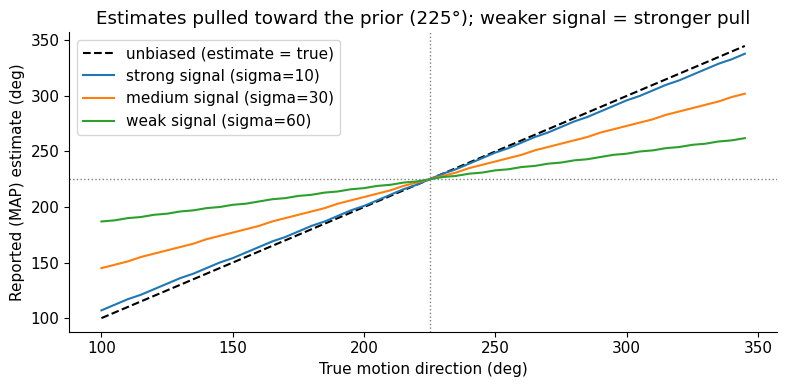

In [8]:
def bayesian_estimate(measurement, prior_mean, prior_sigma, sensory_sigma):
    """MAP estimate for one noisy measurement (Steps 2-5 combined)."""
    prior = my_gaussian(x, prior_mean, prior_sigma)
    likelihood = my_gaussian(x, measurement, sensory_sigma)
    posterior = compute_posterior(prior, likelihood)
    return x[np.argmax(posterior)]


true_dirs = np.arange(100, 350, 5)
coherences = {'strong signal (sigma=10)': 10,
              'medium signal (sigma=30)': 30,
              'weak signal (sigma=60)': 60}

plt.plot(true_dirs, true_dirs, 'k--', label='unbiased (estimate = true)')
for label, sensory_sigma in coherences.items():
    estimates = [bayesian_estimate(d, PRIOR_MEAN, PRIOR_SIGMA, sensory_sigma) for d in true_dirs]
    plt.plot(true_dirs, estimates, label=label)

plt.axhline(PRIOR_MEAN, color='gray', ls=':', lw=1)
plt.axvline(PRIOR_MEAN, color='gray', ls=':', lw=1)
plt.title('Estimates pulled toward the prior (225°); weaker signal = stronger pull')
plt.xlabel('True motion direction (deg)'); plt.ylabel('Reported (MAP) estimate (deg)')
plt.legend(); plt.show()

## What this is and where to take it

A minimal Bayesian observer: a prior, a likelihood, one multiply, a MAP readout — the machinery from **W3D2 Tutorial 2**. It reproduces the paper's central qualitative effect: **estimates are attracted to the prior, and the attraction grows as sensory reliability drops.**

Next steps:

- **Circular version.** Directions live on a circle (359° and 1° are neighbours). Swap `my_gaussian` for a Von Mises (`scipy.stats.vonmises`), concentration κ ≈ 1/σ². See W3D2 for the circular treatment.
- **Fit to data.** Compute the negative log likelihood of a subject's reports under this model and fit `prior_sigma` / `sensory_sigma` — the parameter-recovery workflow in **W3D2 Tutorial 3** (+ W1D2 Model Fitting). Real data lives in `laquitaine_human_errors.ipynb`.
- **Loss functions.** MAP is one readout; the posterior mean minimizes squared error. W3D2 Tutorial 2 covers expected-utility readouts.

## Step 7 — Block-level assumptions: online vs static prior

Steps 1–6 used **one fixed prior**. But across a block of trials, *where does that prior come from and does it change?* Two competing assumptions (the core static-vs-online comparison in the Laquitaine template):

1. **Online Bayesian model (serial dependence)** — the subject updates its prior on **every trial** from the feedback, so the prior **keeps evolving** throughout the block.
2. **Static Bayesian model** — the subject **learns the prior fast** (within `N_LEARN` trials) and then **holds it fixed** for the rest of the block.

Below: simulate one block, then run both models on the same trials and compare.

In [ ]:
# @title Simulate one block of trials (shared by both models)
# True directions drawn from the experimental prior. Each trial the subject gets a
# noisy measurement and then feedback (the true direction).
BLOCK_MEAN    = 225   # true generative prior mean for this block
BLOCK_SIGMA   = 40    # true generative prior spread
N_TRIALS      = 400
SENSORY_SIGMA = 30    # sensory noise (fixed here)
rng = np.random.default_rng(0)

true_dirs    = np.clip(np.round(rng.normal(BLOCK_MEAN, BLOCK_SIGMA, N_TRIALS)), x[0], x[-1]).astype(int)
measurements = np.clip(np.round(rng.normal(true_dirs, SENSORY_SIGMA)),          x[0], x[-1]).astype(int)
feedback     = true_dirs   # subject is shown the true direction as feedback

print(f'{N_TRIALS} trials, true prior mean {BLOCK_MEAN}° +/- {BLOCK_SIGMA}°')

### Assumption 1 — Online Bayesian model (serial dependence)

The subject **updates its prior on every trial** from the feedback, so the prior keeps evolving across the whole block. The prior stays Gaussian with fixed width, but its **mean drifts toward each trial's feedback** via a delta rule (learning rate `LR`):

`prior_mean <- prior_mean + LR * (feedback - prior_mean)`

Because the prior mean tracks recent feedback, this trial's estimate depends on recent trials — the signature of **serial dependence**. Small `LR` = sluggish, long memory; large `LR` = jumpy, short memory.

In [ ]:
# @title Online model: prior evolves every trial (serial dependence)
def run_online(measurements, feedback, sensory_sigma, prior_sigma, lr, init_mean):
    """Online Bayesian observer: prior mean nudged toward feedback each trial
    via a delta rule -> the prior keeps evolving across the block."""
    prior_mean = float(init_mean)
    estimates, prior_means = [], []
    for m, fb in zip(measurements, feedback):
        prior = my_gaussian(x, prior_mean, prior_sigma)
        likelihood = my_gaussian(x, m, sensory_sigma)
        posterior = compute_posterior(prior, likelihood)
        estimates.append(x[np.argmax(posterior)])
        prior_means.append(prior_mean)
        prior_mean = prior_mean + lr * (fb - prior_mean)   # update from feedback
    return np.array(estimates), np.array(prior_means)

LR = 0.05            # learning rate: small = long memory, large = jumpy
PRIOR_SIGMA = 40
est_online, priormean_online = run_online(measurements, feedback,
                                          SENSORY_SIGMA, PRIOR_SIGMA,
                                          lr=LR, init_mean=180)

plt.plot(priormean_online, color=[0.85, 0.4, 0], label=f'online prior mean (LR={LR})')
plt.axhline(BLOCK_MEAN, color='gray', ls=':', label=f'true prior mean {BLOCK_MEAN}°')
plt.title('Online model: prior mean keeps evolving across the block')
plt.xlabel('Trial'); plt.ylabel('Prior mean (deg)')
plt.legend(); plt.show()

### What you can and can't observe in real data

The simulation uses four quantities, but a real experiment only *sees* some of them:

| Quantity | Observable? | Notes |
|----------|-------------|-------|
| **stimulus** (true displayed direction) | ✅ yes | the experimenter sets it |
| **estimate** (subject's report) | ✅ yes | the subject reports it |
| **feedback** | ✅ if the task gives it | often just the stimulus shown again |
| **measurement** (internal noisy percept) | ❌ **no** | latent — lives inside the brain |

Key point: **stimulus ≠ measurement**. The stimulus is the true direction on screen (known); the measurement is the brain's *noisy internal reading* of it (`measurement ~ Gaussian(stimulus, sensory_sigma)`), which is never directly observed.

So with real data you have only **stimulus** and **estimate** per trial. You never see a single trial's measurement — you **infer `sensory_sigma`** by fitting: across many trials, the spread of estimates around stimuli reveals how noisy the internal measurement must be.

```
observed:  stimulus, estimate            (per trial)
latent:    measurement                   (integrated out / marginalized)
fit:       sensory_sigma, prior_sigma, (LR or N_LEARN)   via NLL of estimates
```

That "integrate out the unobserved measurement" step is exactly the **marginalization** in **W3D2 Tutorial 3**: compute the likelihood of the *observed estimate* given the stimulus by summing over all possible hidden measurements. That's how a model with an unmeasurable variable still gets fit to data.

### Assumption 2 — Static Bayesian model

The subject **learns the prior fast** — from the first `N_LEARN` trials of feedback — then **holds it fixed** for the rest of the block. We estimate the prior mean from those first `N_LEARN` feedbacks, freeze it, and run standard Bayesian inference (Steps 2–5) with that fixed prior on every trial. No trial-to-trial evolution afterwards, so **no serial dependence** once the warm-up is over.

In [ ]:
# @title Static model: learn prior fast, then freeze
def run_static(measurements, feedback, sensory_sigma, prior_sigma, n_learn):
    """Static Bayesian observer: prior mean learned from the first n_learn
    feedbacks, then held fixed for the whole block."""
    prior_mean = float(np.mean(feedback[:n_learn]))   # learned once, then fixed
    prior = my_gaussian(x, prior_mean, prior_sigma)   # frozen prior
    estimates = []
    for m in measurements:
        likelihood = my_gaussian(x, m, sensory_sigma)
        posterior = compute_posterior(prior, likelihood)
        estimates.append(x[np.argmax(posterior)])
    return np.array(estimates), prior_mean

N_LEARN = 30
est_static, priormean_static = run_static(measurements, feedback,
                                          SENSORY_SIGMA, PRIOR_SIGMA, n_learn=N_LEARN)

print(f'static prior mean (learned from first {N_LEARN} trials): {priormean_static:.1f} deg')
plt.plot(priormean_online, color=[0.85, 0.4, 0], alpha=0.7, label='online prior mean')
plt.axhline(priormean_static, color=[0, 0.5, 0.2], label=f'static prior mean ({priormean_static:.0f}°)')
plt.axhline(BLOCK_MEAN, color='gray', ls=':', label=f'true prior mean {BLOCK_MEAN}°')
plt.title('Static prior (flat) vs online prior (evolving)')
plt.xlabel('Trial'); plt.ylabel('Prior mean (deg)')
plt.legend(); plt.show()

### Comparing the two

Both give a MAP estimate per trial; they differ in the prior's time course:

| | prior over the block | serial dependence |
|---|---|---|
| **Online** | keeps evolving (delta rule) | yes |
| **Static** | fixed after fast warm-up | no |

To decide which the data favour, fit each model's free parameters (online: `LR`, `prior_sigma`; static: `N_LEARN`, `prior_sigma`) by minimizing the **negative log likelihood** of the subject's responses, then compare with **AIC** — exactly the static-vs-online test in the Laquitaine template (see **W3D2 Tutorial 3** + **W1D2 Model Fitting**).

In [ ]:
# @title Compare estimation error of the two models
err_online = est_online - true_dirs
err_static = est_static - true_dirs

plt.plot(err_online, color=[0.85, 0.4, 0], alpha=0.6,
         label=f'online (RMSE {np.sqrt(np.mean(err_online**2)):.1f}°)')
plt.plot(err_static, color=[0, 0.5, 0.2], alpha=0.6,
         label=f'static (RMSE {np.sqrt(np.mean(err_static**2)):.1f}°)')
plt.axhline(0, color='gray', ls=':')
plt.title('Estimate - true direction, per trial')
plt.xlabel('Trial'); plt.ylabel('Signed error (deg)')
plt.legend(); plt.show()